# Notebook 1 — Clasificación de Llantas Dañadas: CNN Entrenada desde Cero

**Proyecto:** Clasificación de Llantas Dañadas mediante Reconocimiento de Textura  
**Dataset:** [Tire Texture Image Recognition — Kaggle](https://www.kaggle.com/datasets/jehanbhathena/tire-texture-image-recognition)  
**Framework:** PyTorch  
**Objetivo de este notebook:** Diseñar, entrenar y evaluar una CNN construida completamente desde cero (*scratch*), aplicar un estudio de ablación sobre tasa de aprendizaje y función de pérdida (BCE vs Focal Loss), analizar el desbalance de clases, y generar visualizaciones Grad-CAM para interpretar las decisiones del modelo.

---

## Estructura del Notebook
| Sección | Contenido |
|---|---|
| 0 | Setup, dependencias y reproducibilidad |
| 1 | EDA y análisis del dataset |
| 2 | Preprocesamiento y pipelines de datos |
| 3 | Arquitectura TireNet (CNN custom) |
| 4 | Estudio de ablación: lr × loss function |
| 5 | Entrenamiento del modelo final |
| 6 | Evaluación completa sobre test set |
| 7 | Interpretabilidad con Grad-CAM |
| 8 | Análisis cualitativo de fallos |
| 9 | Exportación de artefactos a Google Drive |

---
## Sección 0 — Setup, Dependencias y Reproducibilidad

In [1]:
# ── Install dependencies not present in Colab by default ──────────────────────
!pip install -q grad-cam==1.5.4 kaggle seaborn scikit-learn torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 42.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.5 MB/s eta 0:00:00


In [2]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, sys, json, random, shutil, warnings, time
from pathlib import Path
from collections import Counter
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision.utils import make_grid

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from torchmetrics import AUROC

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

warnings.filterwarnings('ignore')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [3]:
# ── Reproducibility: fix all random seeds ────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # disable for full reproducibility

set_seed(SEED)

# ── Global config ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 224       # input resolution for the CNN
BATCH_SIZE = 64        # safe for A100/V100 with 224x224
NUM_EPOCHS = 40        # max epochs (early stopping will cut this)
PATIENCE   = 7         # early-stopping patience
NUM_WORKERS = 2

# ── Output directories ────────────────────────────────────────────────────────
OUTPUT_DIR = Path('/content/outputs/nb1_cnn_scratch')
GRADCAM_DIR = OUTPUT_DIR / 'gradcam_results'
FAILURE_DIR = OUTPUT_DIR / 'failure_analysis'
for d in [OUTPUT_DIR, GRADCAM_DIR, FAILURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
print(f'Output dir: {OUTPUT_DIR}')

Device: cuda
Output dir: /content/outputs/nb1_cnn_scratch


---
## Sección 1 — Descarga del Dataset y EDA

El dataset *Tire Texture Image Recognition* (Kaggle, jehanbhathena) contiene **1,028 imágenes** de texturas de llantas organizadas en dos clases:
- **`cracked`** — llantas con daños visibles (grietas, oxidación superficial)
- **`normal`** — llantas en buen estado

La estructura en disco sigue el patrón `{split}/{class}/imagen.jpg`, con splits de entrenamiento y prueba predefinidos.

In [4]:
# ── Download dataset via kagglehub ────────────────────────────────────────────
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("jehanbhathena/tire-texture-image-recognition")
print("Path to dataset files:", path)

DATA_DIR = Path(path)

# ── Discover actual directory structure ───────────────────────────────────────
for root, dirs, files_list in os.walk(DATA_DIR):
    level = str(root).replace(str(DATA_DIR), '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{Path(root).name}/')
    if level < 3:
        for f in files_list[:3]:
            print(f'{indent}  {f}')

100%|██████████| 708M/708M [00:06<00:00, 108MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jehanbhathena/tire-texture-image-recognition/versions/1
1/
  Tire Textures/
    training_data/
      cracked/
      normal/
    testing_data/
      cracked/
      normal/


In [5]:
# ── Download and unzip the dataset ────────────────────────────────────────────
DATA_DIR = Path('/content/data/tire_texture')
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not any(DATA_DIR.iterdir()):  # skip if already downloaded
    !kaggle datasets download -d jehanbhathena/tire-texture-image-recognition -p /content/data/tire_texture --unzip
    print('Dataset downloaded.')
else:
    print('Dataset already present — skipping download.')

# ── Discover actual directory structure ───────────────────────────────────────
for root, dirs, files_list in os.walk(DATA_DIR):
    level = str(root).replace(str(DATA_DIR), '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{Path(root).name}/')
    if level < 3:
        for f in files_list[:3]:
            print(f'{indent}  {f}')

Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/tire-texture-image-recognition
License(s): CC0-1.0
100% 708M/708M [00:05<00:00, 144MB/s]

Dataset downloaded.
tire_texture/
  Tire Textures/
    training_data/
      cracked/
      normal/
    testing_data/
      cracked/
      normal/


In [6]:
# ── Locate train / val / test splits ─────────────────────────────────────────
# The dataset has training_data/ and testing_data/ folders, each with cracked/ and normal/
# We create a validation split from training data (80/20).

TRAIN_DIR = DATA_DIR / 'Tyre Texture' / 'training_data'  # adjust if structure differs
TEST_DIR  = DATA_DIR / 'Tyre Texture' / 'testing_data'

# Fallback: search recursively for the split folders
def find_split_dir(base: Path, name: str) -> Path:
    for p in base.rglob(name):
        if p.is_dir():
            return p
    raise FileNotFoundError(f'Could not find {name} under {base}')

if not TRAIN_DIR.exists():
    TRAIN_DIR = find_split_dir(DATA_DIR, 'training_data')
if not TEST_DIR.exists():
    TEST_DIR = find_split_dir(DATA_DIR, 'testing_data')

print(f'Train dir: {TRAIN_DIR}')
print(f'Test dir:  {TEST_DIR}')

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
print(f'Classes: {CLASSES}  →  {CLASS2IDX}')

Train dir: /content/data/tire_texture/Tire Textures/training_data
Test dir:  /content/data/tire_texture/Tire Textures/testing_data
Classes: ['cracked', 'normal']  →  {'cracked': 0, 'normal': 1}


In [7]:
# ── Count images per class per split ─────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def count_images(split_dir: Path) -> dict:
    counts = {}
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = len([f for f in cls_dir.iterdir()
                                        if f.suffix.lower() in IMG_EXTS])
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({
    'Train': train_counts,
    'Test':  test_counts
}).fillna(0).astype(int)
df_counts['Total'] = df_counts.sum(axis=1)
df_counts.loc['TOTAL'] = df_counts.sum()

print('\n=== Distribución de imágenes por clase y split ===')
print(df_counts.to_string())

# ── Class imbalance ratio ─────────────────────────────────────────────────────
cls_names = [c for c in df_counts.index if c != 'TOTAL']
if len(cls_names) == 2:
    n0 = df_counts.loc[cls_names[0], 'Train']
    n1 = df_counts.loc[cls_names[1], 'Train']
    ratio = max(n0, n1) / min(n0, n1)
    print(f'\nImbalance ratio (train): {ratio:.2f}:1  →  ', end='')
    if ratio < 1.5:
        print('desbalance LEVE')
    elif ratio < 3:
        print('desbalance MODERADO')
    else:
        print('desbalance SEVERO — estrategia de mitigación recomendada')


=== Distribución de imágenes por clase y split ===
         Train  Test  Total
cracked    327   210    537
normal     376   115    491
TOTAL      703   325   1028

Imbalance ratio (train): 1.15:1  →  desbalance LEVE


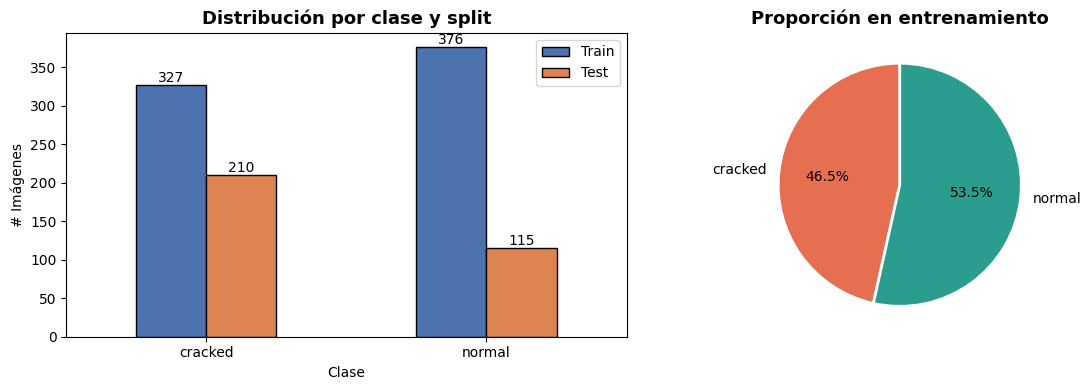

Guardado: eda_class_distribution.png


In [8]:
# ── Visualize class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_plot = df_counts.drop('TOTAL').drop('Total', axis=1)
df_plot.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Distribución por clase y split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('# Imágenes')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10)

train_vals = [train_counts[c] for c in CLASSES]
axes[1].pie(train_vals, labels=CLASSES, autopct='%1.1f%%',
            colors=['#E76F51', '#2A9D8F'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción en entrenamiento', fontsize=13, fontweight='bold')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: eda_class_distribution.png')

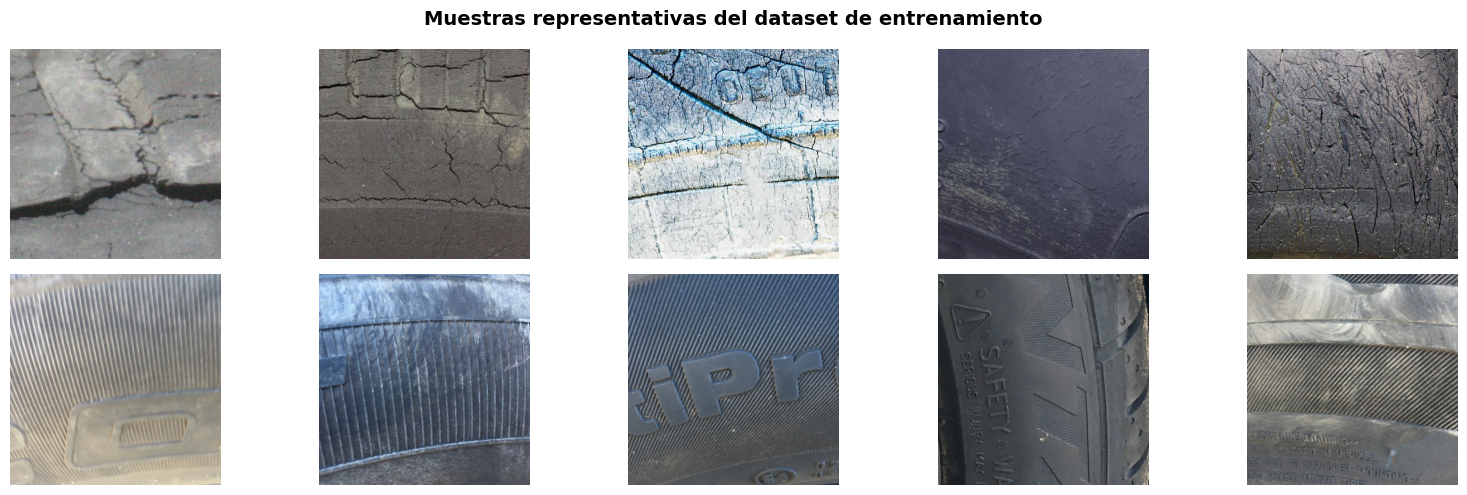

In [9]:
# ── Sample images: visual inspection of both classes ─────────────────────────
def collect_image_paths(split_dir: Path) -> dict:
    paths = {}
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            paths[cls_dir.name] = sorted([
                p for p in cls_dir.iterdir() if p.suffix.lower() in IMG_EXTS
            ])
    return paths

train_paths = collect_image_paths(TRAIN_DIR)
test_paths  = collect_image_paths(TEST_DIR)

n_samples = 5
fig, axes = plt.subplots(len(CLASSES), n_samples, figsize=(16, 5))
fig.suptitle('Muestras representativas del dataset de entrenamiento', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    samples = random.sample(train_paths[cls], min(n_samples, len(train_paths[cls])))
    for col, img_path in enumerate(samples):
        img = Image.open(img_path).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls.upper(), fontsize=11, fontweight='bold',
                                       rotation=90, labelpad=5)
            axes[row, col].yaxis.set_label_position('left')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

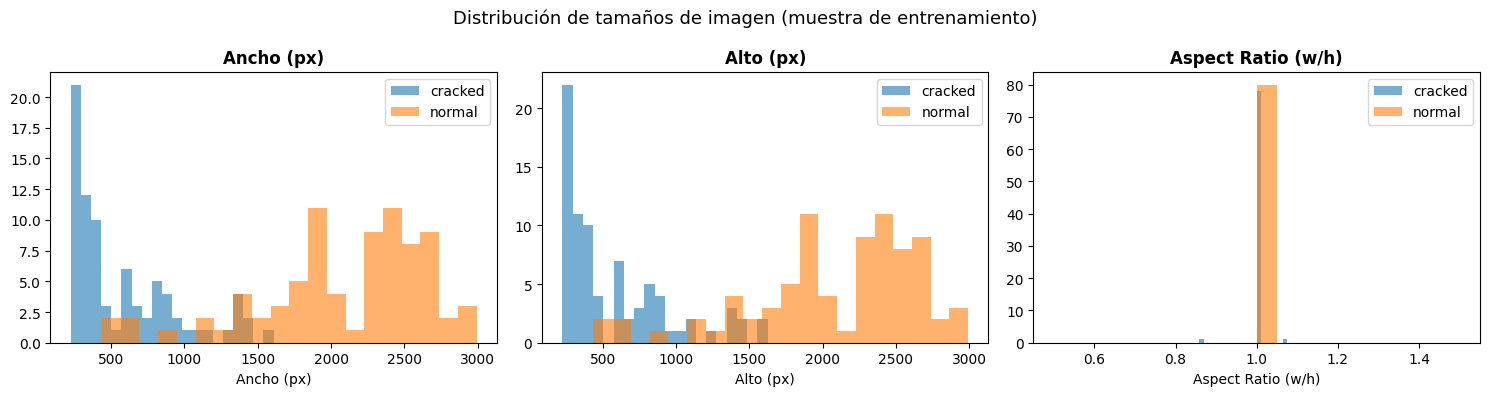

        width                                                       height                                                      
        count    mean    std    min     25%     50%     75%     max  count    mean    std    min     25%     50%     75%     max
class                                                                                                                           
cracked  80.0   571.6  368.5  224.0   268.8   397.5   792.0  1608.0   80.0   574.2  376.1  224.0   268.8   397.5   792.0  1626.0
normal   80.0  2079.2  585.7  437.0  1811.5  2265.0  2496.8  2994.0   80.0  2079.2  585.7  437.0  1811.5  2265.0  2496.8  2994.0


In [10]:
# ── Image size distribution ───────────────────────────────────────────────────
sizes = []
for cls, paths in train_paths.items():
    for p in paths[:80]:  # sample for speed
        w, h = Image.open(p).size
        sizes.append({'class': cls, 'width': w, 'height': h, 'aspect': w/h})

df_sizes = pd.DataFrame(sizes)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['width', 'height', 'aspect'],
                          ['Ancho (px)', 'Alto (px)', 'Aspect Ratio (w/h)']):
    for cls in CLASSES:
        ax.hist(df_sizes[df_sizes['class']==cls][col], bins=20, alpha=0.6, label=cls)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_xlabel(title)

fig.suptitle('Distribución de tamaños de imagen (muestra de entrenamiento)', fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_sizes.groupby('class')[['width','height']].describe().round(1).to_string())

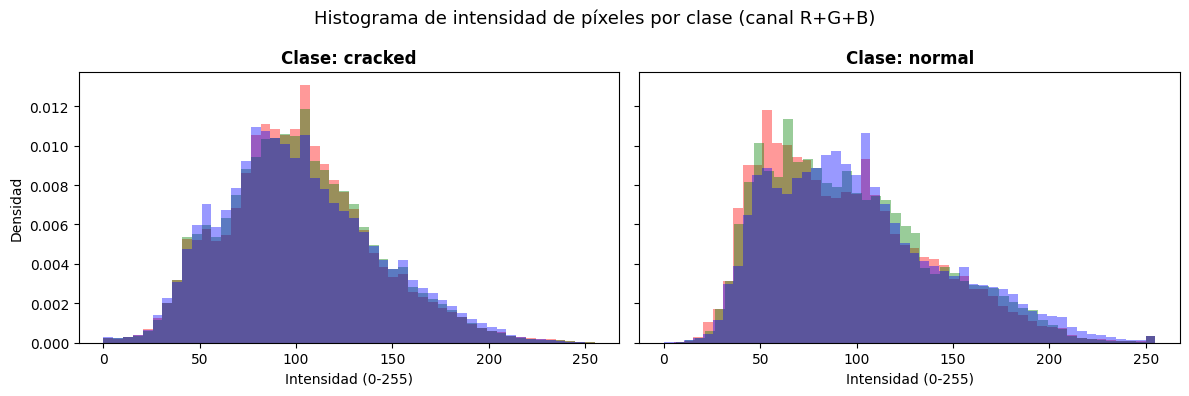

In [11]:
# ── Pixel intensity histograms per class ──────────────────────────────────────
# A difference in distribution may indicate texture-level discriminability
fig, axes = plt.subplots(1, len(CLASSES), figsize=(12, 4), sharey=True)
fig.suptitle('Histograma de intensidad de píxeles por clase (canal R+G+B)', fontsize=13)

colors_rgb = ['red', 'green', 'blue']
for ax, cls in zip(axes, CLASSES):
    sample = random.sample(train_paths[cls], min(40, len(train_paths[cls])))
    for ch_idx, ch_color in enumerate(colors_rgb):
        all_vals = []
        for p in sample:
            img_arr = np.array(Image.open(p).convert('RGB').resize((128, 128)))
            all_vals.extend(img_arr[:, :, ch_idx].flatten().tolist())
        ax.hist(all_vals, bins=50, color=ch_color, alpha=0.4, density=True)
    ax.set_title(f'Clase: {cls}', fontweight='bold')
    ax.set_xlabel('Intensidad (0-255)')

axes[0].set_ylabel('Densidad')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'eda_intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Save EDA summary CSV ──────────────────────────────────────────────────────
df_counts.to_csv(OUTPUT_DIR / 'eda_summary.csv')
print('EDA summary guardado.')

EDA summary guardado.


---
## Sección 2 — Preprocesamiento y Pipelines de Datos

Se implementan **dos pipelines de augmentation** para el estudio de ablación:
- **Baseline:** Solo flip horizontal + normalización ImageNet. Mínima modificación a los datos.
- **Agresivo:** Rotaciones, jitter de color, perspectiva aleatoria, random erasing, y elastic transform. Diseñado para forzar invarianza a condiciones de captura variables.

Para la mitigación del desbalance, se implementa `WeightedRandomSampler` que sobremuestra la clase minoritaria durante el entrenamiento, controlado por un flag configurable.

In [13]:
# ── Custom Dataset ────────────────────────────────────────────────────────────
class TireDataset(Dataset):
    """Loads tire images from a folder structured as split/class/image.jpg"""

    def __init__(self, root_dir: Path, transform=None, class2idx: dict = None):
        self.samples = []
        self.class2idx = class2idx or CLASS2IDX
        self.transform = transform

        for cls_name, cls_idx in self.class2idx.items():
            cls_dir = root_dir / cls_name
            if not cls_dir.exists():
                continue
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in IMG_EXTS:
                    self.samples.append((img_path, cls_idx))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, str(img_path)  # return path for failure analysis


# ── ImageNet normalization stats ──────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transform definitions ─────────────────────────────────────────────────────
transform_baseline = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_aggressive = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=25),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomPerspective(distortion_scale=0.3, p=0.4),
    T.ToTensor(),
    T.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined:')
print('  - transform_baseline  (flip + normalize)')
print('  - transform_aggressive (crop, rotate, jitter, erase + normalize)')
print('  - transform_eval      (resize + normalize, no augmentation)')

Transforms defined:
  - transform_baseline  (flip + normalize)
  - transform_aggressive (crop, rotate, jitter, erase + normalize)
  - transform_eval      (resize + normalize, no augmentation)


In [14]:
# ── Create train/val split from training_data (80/20 stratified) ──────────────
from sklearn.model_selection import train_test_split

all_train_paths = train_paths  # dict {cls: [paths]}

# Flatten with labels
all_samples = []
for cls, paths in all_train_paths.items():
    for p in paths:
        all_samples.append((p, CLASS2IDX[cls]))

train_samples, val_samples = train_test_split(
    all_samples,
    test_size=0.20,
    stratify=[s[1] for s in all_samples],
    random_state=SEED
)

print(f'Train samples: {len(train_samples)}')
print(f'Val samples:   {len(val_samples)}')
print(f'Test samples:  {sum(len(p) for p in test_paths.values())}')

# Count train labels
train_labels = [s[1] for s in train_samples]
label_counts = Counter(train_labels)
print(f'\nTrain label counts: {dict(label_counts)}')

Train samples: 562
Val samples:   141
Test samples:  325

Train label counts: {1: 301, 0: 261}


In [15]:
# ── Dataset with pre-split sample lists ───────────────────────────────────────
class TireDatasetFromList(Dataset):
    """Dataset initialized from a list of (path, label) tuples."""

    def __init__(self, samples: list, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, str(img_path)


# ── WeightedRandomSampler for imbalance mitigation ───────────────────────────
def build_weighted_sampler(samples: list) -> WeightedRandomSampler:
    """Oversample minority class so each mini-batch is roughly balanced."""
    labels = [s[1] for s in samples]
    class_counts = Counter(labels)
    total = len(labels)
    class_weights = {cls: total / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[lbl] for lbl in labels]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float),
        num_samples=len(labels),
        replacement=True
    )


def build_dataloaders(augmentation: str = 'baseline',
                      use_weighted_sampler: bool = True,
                      batch_size: int = BATCH_SIZE):
    """Build train/val/test DataLoaders.

    Args:
        augmentation: 'baseline' or 'aggressive'
        use_weighted_sampler: if True, apply WeightedRandomSampler on train set
        batch_size: mini-batch size
    """
    aug = transform_baseline if augmentation == 'baseline' else transform_aggressive

    ds_train = TireDatasetFromList(train_samples, transform=aug)
    ds_val   = TireDatasetFromList(val_samples,   transform=transform_eval)
    ds_test  = TireDataset(TEST_DIR, transform=transform_eval)

    sampler = build_weighted_sampler(train_samples) if use_weighted_sampler else None
    shuffle = not use_weighted_sampler  # mutually exclusive with sampler

    dl_train = DataLoader(ds_train, batch_size=batch_size, sampler=sampler,
                          shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

    return dl_train, dl_val, dl_test

print('DataLoader factory ready.')

DataLoader factory ready.


---
## Sección 3 — Arquitectura TireNet (CNN desde Cero)

**TireNet** es una CNN diseñada con los siguientes principios:

1. **5 bloques convolucionales progresivos:** Cada bloque sigue el patrón `Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool`. Los filtros se duplican progresivamente (32 → 64 → 128 → 256 → 256) para capturar características de bajo nivel (bordes, texturas) en capas tempranas y representaciones semánticas en capas profundas.

2. **Residual shortcut simplificado en bloques 3-5:** Suma residual 1×1 para facilitar el flujo de gradientes sin la complejidad total de ResNet.

3. **Cabeza clasificadora con Dropout progresivo:** `GAP → FC(512) → Dropout(0.5) → FC(128) → Dropout(0.3) → FC(1)`. El Global Average Pooling elimina la dependencia del tamaño de entrada y reduce parámetros.

4. **Salida escalar (sin Sigmoid):** Compatible con `BCEWithLogitsLoss` y `FocalLoss`, que incorporan el Sigmoid internamente de forma numéricamente estable.

In [16]:
# ── Convolutional Block ───────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Double Conv → BN → ReLU block with optional residual shortcut."""

    def __init__(self, in_ch: int, out_ch: int, use_residual: bool = False):
        super().__init__()
        self.use_residual = use_residual

        self.conv1 = nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(2, 2)

        # 1×1 projection for residual when channel dims differ
        if use_residual:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = None

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_residual and self.shortcut is not None:
            out = out + self.shortcut(identity)
        out = self.relu(out)
        return self.pool(out)


# ── TireNet ───────────────────────────────────────────────────────────────────
class TireNet(nn.Module):
    """Custom CNN for binary tire damage classification.

    Architecture:
        Block 1: 3   → 32   (no residual)
        Block 2: 32  → 64   (no residual)
        Block 3: 64  → 128  (residual)
        Block 4: 128 → 256  (residual)
        Block 5: 256 → 256  (residual)
        GAP → FC(512) → Dropout(0.5) → FC(128) → Dropout(0.3) → FC(1)
    """

    def __init__(self, dropout_rates: tuple = (0.5, 0.3)):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  use_residual=False),  # 224 → 112
            ConvBlock(32,  64,  use_residual=False),  # 112 → 56
            ConvBlock(64,  128, use_residual=True),   # 56  → 28
            ConvBlock(128, 256, use_residual=True),   # 28  → 14
            ConvBlock(256, 256, use_residual=True),   # 14  → 7
        )
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling → (B, 256, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rates[0]),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rates[1]),
            nn.Linear(128, 1),  # raw logit — no Sigmoid here
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)  # shape: (B, 1)


# ── Quick sanity check ────────────────────────────────────────────────────────
def count_params(model: nn.Module) -> dict:
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {'total': total, 'trainable': trainable}

model_scratch = TireNet().to(DEVICE)
params = count_params(model_scratch)
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out = model_scratch(dummy)

print(f'TireNet output shape: {out.shape}  (expected: [2, 1])')
print(f'Total parameters:     {params["total"]:,}')
print(f'Trainable parameters: {params["trainable"]:,}')

TireNet output shape: torch.Size([2, 1])  (expected: [2, 1])
Total parameters:     2,659,041
Trainable parameters: 2,659,041


In [17]:
# ── Focal Loss implementation ─────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Binary Focal Loss for imbalanced classification.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha: weighting factor for the positive class (default: 0.25)
        gamma: focusing parameter; gamma=0 reduces to BCE (default: 2.0)
    """

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float().unsqueeze(1) if logits.dim() > targets.dim() else targets.float()
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = torch.exp(-bce_loss)  # probability of correct class
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * ((1 - p_t) ** self.gamma) * bce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ── Compute class weights for weighted BCE ────────────────────────────────────
def compute_pos_weight(samples: list) -> torch.Tensor:
    """pos_weight = n_neg / n_pos, passed to BCEWithLogitsLoss."""
    labels = [s[1] for s in samples]
    n_pos = sum(labels)           # class 1 = cracked
    n_neg = len(labels) - n_pos   # class 0 = normal
    pos_weight = n_neg / max(n_pos, 1)
    print(f'  n_pos={n_pos}, n_neg={n_neg}, pos_weight={pos_weight:.3f}')
    return torch.tensor([pos_weight], dtype=torch.float).to(DEVICE)

pos_weight = compute_pos_weight(train_samples)

LOSS_FUNCTIONS = {
    'bce':   nn.BCEWithLogitsLoss(pos_weight=pos_weight),
    'focal': FocalLoss(alpha=0.25, gamma=2.0),
}

print('Loss functions ready:', list(LOSS_FUNCTIONS.keys()))

  n_pos=301, n_neg=261, pos_weight=0.867
Loss functions ready: ['bce', 'focal']


---
## Sección 4 — Estudio de Ablación: lr × Función de Pérdida

Se evalúan **4 configuraciones** resultantes del cruce de:
- **Tasa de aprendizaje:** `1e-3` (alta, convergencia rápida pero riesgo de inestabilidad) vs `1e-4` (conservadora)
- **Función de pérdida:** `BCE ponderada` (clase weight estándar) vs `Focal Loss` (enfocada en ejemplos difíciles)

Cada configuración se entrena por `15 épocas` (reducido para viabilidad computacional del ablation), el modelo final usa la mejor configuración encontrada.

In [18]:
# ── Training loop utility ─────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels, _ in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device).unsqueeze(1)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for imgs, labels, _ in loader:
        imgs   = imgs.to(device)
        labels_dev = labels.float().to(device).unsqueeze(1)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels_dev)
        probs = torch.sigmoid(logits).squeeze(1).cpu()
        preds = (probs >= 0.5).long()
        total_loss += loss.item() * imgs.size(0)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

    n = len(all_labels)
    metrics = {
        'loss':      total_loss / n,
        'accuracy':  accuracy_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'auc':       roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        'probs':     all_probs,
        'preds':     all_preds,
        'labels':    all_labels,
    }
    return metrics

print('Training utilities defined.')

Training utilities defined.


In [19]:
# ── Ablation configuration ────────────────────────────────────────────────────
ABLATION_CONFIGS = [
    {'name': 'lr=1e-3 | BCE',   'lr': 1e-3, 'loss': 'bce'},
    {'name': 'lr=1e-3 | Focal', 'lr': 1e-3, 'loss': 'focal'},
    {'name': 'lr=1e-4 | BCE',   'lr': 1e-4, 'loss': 'bce'},
    {'name': 'lr=1e-4 | Focal', 'lr': 1e-4, 'loss': 'focal'},
]
ABLATION_EPOCHS = 15

ablation_results = []
dl_train_abl, dl_val_abl, _ = build_dataloaders(augmentation='baseline',
                                                  use_weighted_sampler=True)

for cfg in ABLATION_CONFIGS:
    print(f'\n{"─"*60}')
    print(f'Running: {cfg["name"]}')
    set_seed(SEED)

    model_abl   = TireNet().to(DEVICE)
    criterion   = LOSS_FUNCTIONS[cfg['loss']]
    optimizer   = torch.optim.AdamW(model_abl.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    scaler      = GradScaler()
    best_f1_abl = 0.0

    for epoch in range(1, ABLATION_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model_abl, dl_train_abl, optimizer, criterion, scaler, DEVICE)
        val_metrics     = evaluate(model_abl, dl_val_abl, criterion, DEVICE)
        if val_metrics['f1'] > best_f1_abl:
            best_f1_abl = val_metrics['f1']
        if epoch % 5 == 0:
            print(f'  Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_f1={val_metrics["f1"]:.4f} | val_auc={val_metrics["auc"]:.4f}')

    val_final = evaluate(model_abl, dl_val_abl, criterion, DEVICE)
    ablation_results.append({
        'config':    cfg['name'],
        'lr':        cfg['lr'],
        'loss_fn':   cfg['loss'],
        'val_loss':  val_final['loss'],
        'val_acc':   val_final['accuracy'],
        'val_f1':    val_final['f1'],
        'val_auc':   val_final['auc'],
        'best_f1':   best_f1_abl,
    })
    del model_abl
    torch.cuda.empty_cache()

df_ablation = pd.DataFrame(ablation_results)
print('\n=== Resultados del Estudio de Ablación ===')
print(df_ablation[['config', 'val_acc', 'val_f1', 'val_auc', 'val_loss']].to_string(index=False))
df_ablation.to_csv(OUTPUT_DIR / 'ablation_results.csv', index=False)
print('\nGuardado: ablation_results.csv')


────────────────────────────────────────────────────────────
Running: lr=1e-3 | BCE
  Epoch 05 | train_loss=0.4900 | val_f1=0.7364 | val_auc=0.7703
  Epoch 10 | train_loss=0.3898 | val_f1=0.5983 | val_auc=0.8090
  Epoch 15 | train_loss=0.3188 | val_f1=0.8082 | val_auc=0.8896

────────────────────────────────────────────────────────────
Running: lr=1e-3 | Focal
  Epoch 05 | train_loss=0.0546 | val_f1=0.6339 | val_auc=0.7864
  Epoch 10 | train_loss=0.0481 | val_f1=0.6557 | val_auc=0.7677
  Epoch 15 | train_loss=0.0386 | val_f1=0.7655 | val_auc=0.8733

────────────────────────────────────────────────────────────
Running: lr=1e-4 | BCE
  Epoch 05 | train_loss=0.4483 | val_f1=0.6711 | val_auc=0.8527
  Epoch 10 | train_loss=0.2578 | val_f1=0.8214 | val_auc=0.8827
  Epoch 15 | train_loss=0.2237 | val_f1=0.8438 | val_auc=0.9046

────────────────────────────────────────────────────────────
Running: lr=1e-4 | Focal
  Epoch 05 | train_loss=0.0519 | val_f1=0.7736 | val_auc=0.8294
  Epoch 10 | tra

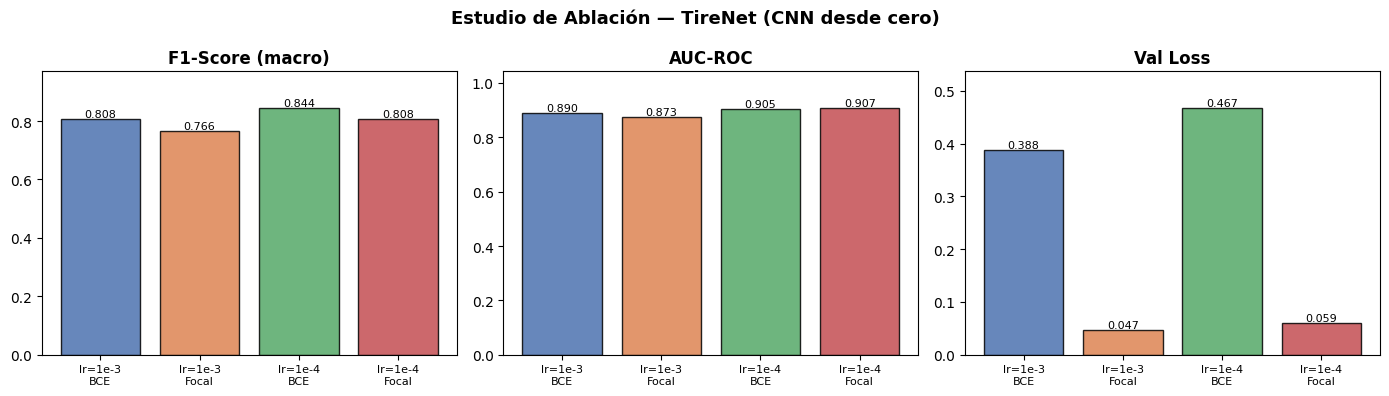


→ Mejor configuración: LR=0.0001, Loss=BCE (val_f1=0.8438)


In [20]:
# ── Visualize ablation results ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Estudio de Ablación — TireNet (CNN desde cero)', fontsize=13, fontweight='bold')

metrics_to_plot = [('val_f1', 'F1-Score (macro)'), ('val_auc', 'AUC-ROC'), ('val_loss', 'Val Loss')]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (col, title) in zip(axes, metrics_to_plot):
    bars = ax.bar(range(len(df_ablation)), df_ablation[col], color=colors, edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(df_ablation)))
    ax.set_xticklabels([c.replace(' | ', '\n') for c in df_ablation['config']], fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.bar_label(bars, fmt='%.3f', fontsize=8)
    ax.set_ylim(0, max(df_ablation[col]) * 1.15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'ablation_results_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify best config
best_row = df_ablation.loc[df_ablation['val_f1'].idxmax()]
BEST_LR   = best_row['lr']
BEST_LOSS = best_row['loss_fn']
print(f'\n→ Mejor configuración: LR={BEST_LR}, Loss={BEST_LOSS.upper()} (val_f1={best_row["val_f1"]:.4f})')

---
## Sección 5 — Entrenamiento del Modelo Final

El modelo final se entrena usando la mejor configuración identificada en el estudio de ablación, con:
- **Early stopping** con paciencia configurable (monitorea val-F1 macro)
- **ReduceLROnPlateau** como scheduler (factor=0.5, paciencia=3)
- **Mixed Precision Training** (`torch.cuda.amp`) para máxima velocidad en A100/V100
- **Checkpoint del mejor modelo** guardado automáticamente

In [21]:
# ── Build final dataloaders with best augmentation ────────────────────────────
dl_train, dl_val, dl_test = build_dataloaders(
    augmentation='aggressive',     # use aggressive augmentation for final model
    use_weighted_sampler=True,
    batch_size=BATCH_SIZE
)

# ── Initialize final model ────────────────────────────────────────────────────
set_seed(SEED)
model = TireNet().to(DEVICE)
criterion = LOSS_FUNCTIONS[BEST_LOSS]
optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)
scaler = GradScaler()

# ── Training loop with early stopping ────────────────────────────────────────
CKPT_PATH = OUTPUT_DIR / 'best_model.pth'
best_val_f1   = 0.0
patience_ctr  = 0
history       = []

print(f'Training TireNet | LR={BEST_LR} | Loss={BEST_LOSS.upper()} | Epochs={NUM_EPOCHS}')
print('─' * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, dl_train, optimizer, criterion, scaler, DEVICE)
    val_metrics     = evaluate(model, dl_val, criterion, DEVICE)
    scheduler.step(val_metrics['f1'])

    lr_now = optimizer.param_groups[0]['lr']
    row = {
        'epoch': epoch, 'lr': lr_now,
        'train_loss': tr_loss, 'train_acc': tr_acc,
        'val_loss': val_metrics['loss'],
        'val_acc':  val_metrics['accuracy'],
        'val_f1':   val_metrics['f1'],
        'val_auc':  val_metrics['auc'],
    }
    history.append(row)

    improved = val_metrics['f1'] > best_val_f1
    if improved:
        best_val_f1 = val_metrics['f1']
        patience_ctr = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_f1': best_val_f1}, CKPT_PATH)
    else:
        patience_ctr += 1

    flag = '★ NEW BEST' if improved else f'patience {patience_ctr}/{PATIENCE}'
    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'tr_loss={tr_loss:.4f} | tr_acc={tr_acc:.4f} | '
          f'val_f1={val_metrics["f1"]:.4f} | val_auc={val_metrics["auc"]:.4f} | '
          f'lr={lr_now:.2e} | {time.time()-t0:.1f}s | {flag}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest val F1: {best_val_f1:.4f}  →  checkpoint: {CKPT_PATH}')

Training TireNet | LR=0.0001 | Loss=BCE | Epochs=40
───────────────────────────────────────────────────────────────────────────
Ep 01/40 | tr_loss=0.6298 | tr_acc=0.6068 | val_f1=0.3472 | val_auc=0.4302 | lr=1.00e-04 | 14.6s | ★ NEW BEST
Ep 02/40 | tr_loss=0.5858 | tr_acc=0.6495 | val_f1=0.3472 | val_auc=0.5711 | lr=1.00e-04 | 14.6s | patience 1/7
Ep 03/40 | tr_loss=0.5366 | tr_acc=0.7100 | val_f1=0.3472 | val_auc=0.7305 | lr=1.00e-04 | 13.5s | patience 2/7
Ep 04/40 | tr_loss=0.5344 | tr_acc=0.6993 | val_f1=0.5874 | val_auc=0.7615 | lr=1.00e-04 | 14.9s | ★ NEW BEST
Ep 05/40 | tr_loss=0.5263 | tr_acc=0.7117 | val_f1=0.6936 | val_auc=0.8380 | lr=1.00e-04 | 14.2s | ★ NEW BEST
Ep 06/40 | tr_loss=0.5049 | tr_acc=0.7402 | val_f1=0.7299 | val_auc=0.7669 | lr=1.00e-04 | 14.5s | ★ NEW BEST
Ep 07/40 | tr_loss=0.4905 | tr_acc=0.7278 | val_f1=0.7446 | val_auc=0.8262 | lr=1.00e-04 | 13.7s | ★ NEW BEST
Ep 08/40 | tr_loss=0.4903 | tr_acc=0.7598 | val_f1=0.7660 | val_auc=0.8726 | lr=1.00e-04 | 15.5s |

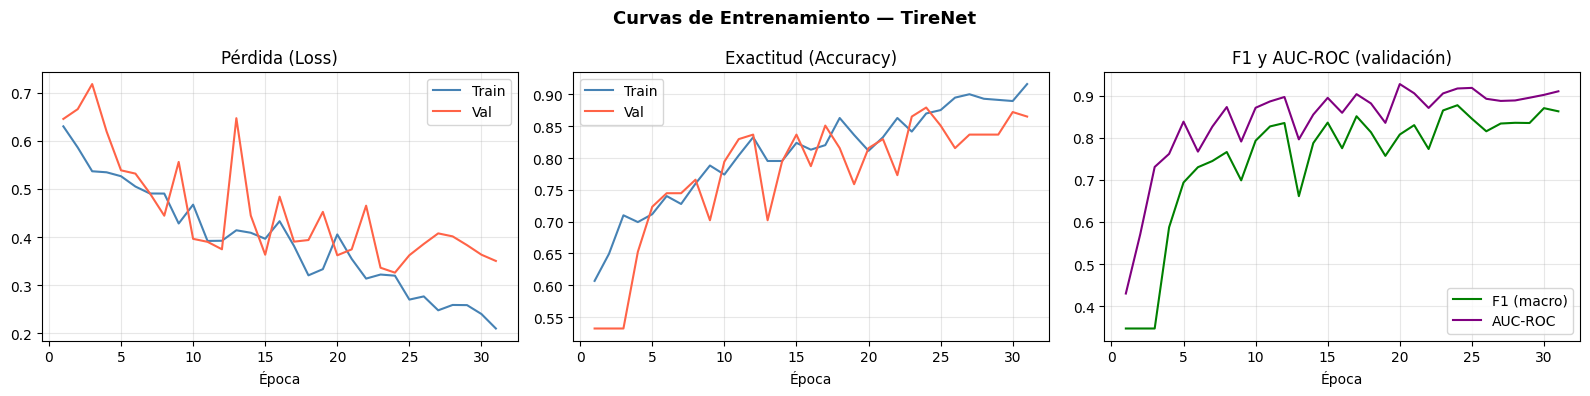

In [22]:
# ── Save training history and plot curves ─────────────────────────────────────
df_history = pd.DataFrame(history)
df_history.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de Entrenamiento — TireNet', fontsize=13, fontweight='bold')

axes[0].plot(df_history['epoch'], df_history['train_loss'], label='Train', color='steelblue')
axes[0].plot(df_history['epoch'], df_history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Pérdida (Loss)'); axes[0].legend(); axes[0].set_xlabel('Época')

axes[1].plot(df_history['epoch'], df_history['train_acc'], label='Train', color='steelblue')
axes[1].plot(df_history['epoch'], df_history['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Exactitud (Accuracy)'); axes[1].legend(); axes[1].set_xlabel('Época')

axes[2].plot(df_history['epoch'], df_history['val_f1'],  label='F1 (macro)', color='green')
axes[2].plot(df_history['epoch'], df_history['val_auc'], label='AUC-ROC',    color='purple')
axes[2].set_title('F1 y AUC-ROC (validación)'); axes[2].legend(); axes[2].set_xlabel('Época')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 6 — Evaluación Completa sobre Test Set

Se carga el checkpoint del mejor modelo y se evalúa sobre el test set con **métricas completas**. Se incluye una comparación explícita entre el modelo **con** y **sin** estrategia de mitigación de desbalance (`WeightedRandomSampler`) para cuantificar su impacto.

In [23]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]} (val_f1={checkpoint["val_f1"]:.4f})')

# ── Full test evaluation ──────────────────────────────────────────────────────
test_metrics = evaluate(model, dl_test, criterion, DEVICE)

y_true  = test_metrics['labels']
y_pred  = test_metrics['preds']
y_probs = test_metrics['probs']

precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per_class    = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per_class        = f1_score(y_true, y_pred, average=None, zero_division=0)

print('\n=== Métricas sobre Test Set ===')
print(f'  Accuracy:           {accuracy_score(y_true, y_pred):.4f}')
print(f'  Precision (macro):  {precision_score(y_true, y_pred, average="macro", zero_division=0):.4f}')
print(f'  Recall (macro):     {recall_score(y_true, y_pred, average="macro", zero_division=0):.4f}')
print(f'  F1-Score (macro):   {f1_score(y_true, y_pred, average="macro", zero_division=0):.4f}')
print(f'  F1-Score (weighted):{f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'  AUC-ROC:            {roc_auc_score(y_true, y_probs):.4f}')
print('\nPer-class breakdown:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:8s} | Precision={precision_per_class[i]:.4f} | Recall={recall_per_class[i]:.4f} | F1={f1_per_class[i]:.4f}')

print('\n', classification_report(y_true, y_pred, target_names=CLASSES))

Loaded checkpoint from epoch 24 (val_f1=0.8770)

=== Métricas sobre Test Set ===
  Accuracy:           0.6215
  Precision (macro):  0.6830
  Recall (macro):     0.6816
  F1-Score (macro):   0.6215
  F1-Score (weighted):0.6208
  AUC-ROC:            0.7956

Per-class breakdown:
  cracked  | Precision=0.8850 | Recall=0.4762 | F1=0.6192
  normal   | Precision=0.4811 | Recall=0.8870 | F1=0.6239

               precision    recall  f1-score   support

     cracked       0.88      0.48      0.62       210
      normal       0.48      0.89      0.62       115

    accuracy                           0.62       325
   macro avg       0.68      0.68      0.62       325
weighted avg       0.74      0.62      0.62       325



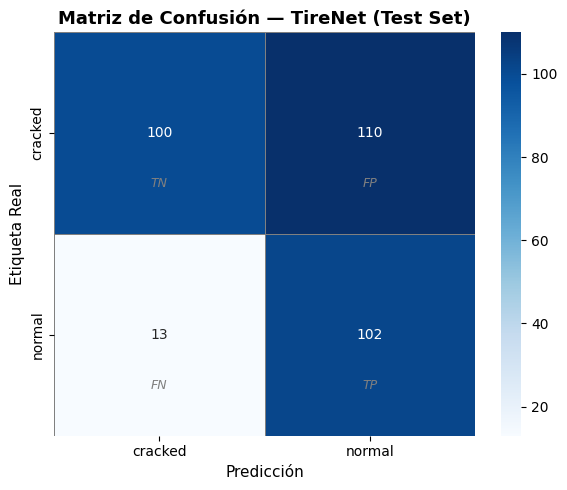

Guardado: confusion_matrix.png


In [24]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray')
ax.set_title('Matriz de Confusión — TireNet (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Etiqueta Real', fontsize=11)

# Add annotations for TP, TN, FP, FN
annotations = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, annotations[i][j],
                ha='center', va='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: confusion_matrix.png')

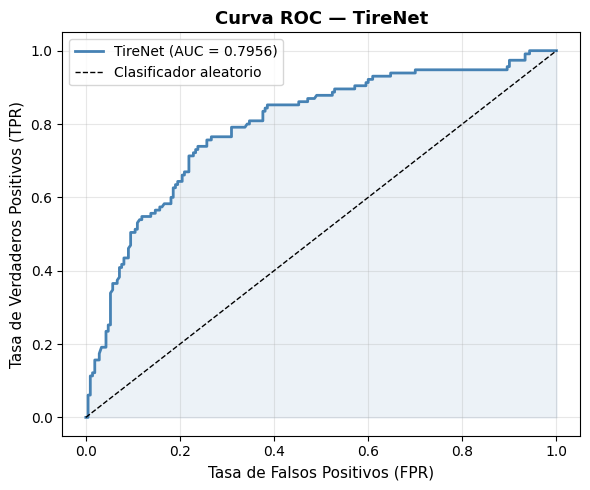

In [25]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
auc_score = roc_auc_score(y_true, y_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'TireNet (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC — TireNet', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── Imbalance mitigation comparison ──────────────────────────────────────────
# Train a second model WITHOUT WeightedRandomSampler to show impact
print('Training baseline (no WeightedRandomSampler) for imbalance comparison...')
set_seed(SEED)
dl_train_nosampler, dl_val_ns, dl_test_ns = build_dataloaders(
    augmentation='aggressive', use_weighted_sampler=False
)
model_ns  = TireNet().to(DEVICE)
crit_ns   = LOSS_FUNCTIONS[BEST_LOSS]
opt_ns    = torch.optim.AdamW(model_ns.parameters(), lr=BEST_LR, weight_decay=1e-4)
scaler_ns = GradScaler()

for ep in range(1, 21):  # 20 epochs for quick comparison
    train_one_epoch(model_ns, dl_train_nosampler, opt_ns, crit_ns, scaler_ns, DEVICE)

ns_metrics = evaluate(model_ns, dl_test_ns, crit_ns, DEVICE)

comparison = pd.DataFrame([
    {
        'Estrategia': 'Sin mitigación (shuffle)',
        'Accuracy': accuracy_score(ns_metrics['labels'], ns_metrics['preds']),
        'F1 (macro)': f1_score(ns_metrics['labels'], ns_metrics['preds'], average='macro', zero_division=0),
        'Recall (cracked)': recall_score(ns_metrics['labels'], ns_metrics['preds'], zero_division=0),
        'AUC-ROC': roc_auc_score(ns_metrics['labels'], ns_metrics['probs']),
    },
    {
        'Estrategia': 'Con WeightedRandomSampler',
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (cracked)': recall_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_probs),
    }
])

print('\n=== Impacto del Desbalance de Clases ===')
print(comparison.set_index('Estrategia').round(4).to_string())
comparison.to_csv(OUTPUT_DIR / 'imbalance_comparison.csv', index=False)
del model_ns; torch.cuda.empty_cache()

Training baseline (no WeightedRandomSampler) for imbalance comparison...

=== Impacto del Desbalance de Clases ===
                           Accuracy  F1 (macro)  Recall (cracked)  AUC-ROC
Estrategia                                                                
Sin mitigación (shuffle)     0.6000      0.5989            0.7739   0.7028
Con WeightedRandomSampler    0.6215      0.6215            0.8870   0.7956


In [27]:
# ── Save test predictions ─────────────────────────────────────────────────────
all_paths = []
model.eval()
with torch.no_grad():
    for _, _, paths in dl_test:
        all_paths.extend(paths)

df_predictions = pd.DataFrame({
    'image_path': all_paths,
    'true_label': [CLASSES[l] for l in y_true],
    'pred_label': [CLASSES[p] for p in y_pred],
    'prob_cracked': y_probs,
    'correct': [t == p for t, p in zip(y_true, y_pred)],
})
df_predictions.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
print(f'Predicciones guardadas: {len(df_predictions)} imágenes')

Predicciones guardadas: 325 imágenes


In [28]:
# ── Save consolidated metrics summary ────────────────────────────────────────
metrics_summary = pd.DataFrame([{
    'model': 'TireNet (CNN Scratch)',
    'accuracy':   accuracy_score(y_true, y_pred),
    'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
    'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    'f1_weighted':     f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'auc_roc':         roc_auc_score(y_true, y_probs),
    'best_epoch':      checkpoint['epoch'],
    'best_lr':         BEST_LR,
    'best_loss_fn':    BEST_LOSS,
}])
metrics_summary.to_csv(OUTPUT_DIR / 'metrics_summary.csv', index=False)
print('metrics_summary.csv guardado.')

metrics_summary.csv guardado.


---
## Sección 7 — Interpretabilidad con Grad-CAM

**Gradient-weighted Class Activation Mapping (Grad-CAM)** permite visualizar qué regiones espaciales de la imagen contribuyen más a la predicción de la red. Se calcula el gradiente de la salida del clasificador respecto a las activaciones de la última capa convolucional, y se promedia globalmente para obtener un mapa de calor por canal.

Se generan visualizaciones para:
1. 4 imágenes de llantas **normales** (2 correctamente clasificadas, 2 incorrectas)
2. 4 imágenes de llantas **dañadas** (2 correctamente clasificadas, 2 incorrectas)

Esto permite distinguir qué patrones aprendió el modelo en predicciones correctas vs erróneas.

In [29]:
# ── Setup Grad-CAM on last ConvBlock ──────────────────────────────────────────
# Target: last block in model.features (index 4 = ConvBlock with 256 channels)
target_layers = [model.features[-1].conv2]  # last conv layer before GAP

cam = GradCAM(model=model, target_layers=target_layers)


def generate_gradcam_image(img_path: str, true_label: int, pred_label: int,
                            prob: float, save_path: Path):
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np  = np.array(img_pil, dtype=np.float32) / 255.0

    tensor = transform_eval(img_pil).unsqueeze(0).to(DEVICE)

    # For binary models with a single output neuron, target index is always 0
    targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_np)
    axes[0].set_title('Original', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cam_image)
    status = '✓ CORRECTO' if true_label == pred_label else '✗ ERROR'
    color  = 'green' if true_label == pred_label else 'red'
    axes[1].set_title(
        f'Grad-CAM | {status}\n'
        f'Real: {CLASSES[true_label]} | Pred: {CLASSES[pred_label]} (p={prob:.2f})',
        color=color, fontweight='bold', fontsize=9
    )
    axes[1].axis('off')

    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.close(fig)


print('Grad-CAM setup complete. Target layer:', target_layers)

Grad-CAM setup complete. Target layer: [Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)]


In [30]:
# ── Select images for Grad-CAM visualization ──────────────────────────────────
df_pred = df_predictions.copy()

# Map labels to indices safely
df_pred['true_idx'] = df_pred['true_label'].map(CLASS2IDX)
df_pred['pred_idx'] = df_pred['pred_label'].map(CLASS2IDX)

# Drop rows where mapping failed (label not in CLASS2IDX)
df_pred = df_pred.dropna(subset=['true_idx', 'pred_idx'])
df_pred['true_idx'] = df_pred['true_idx'].astype(int)
df_pred['pred_idx'] = df_pred['pred_idx'].astype(int)

# Clamp pred_idx to valid range [0, num_classes-1]
n_classes = len(CLASSES)
df_pred['pred_idx'] = df_pred['pred_idx'].clip(0, n_classes - 1)

print(f'Classes in dataset:     {CLASSES}')
print(f'CLASS2IDX mapping:      {CLASS2IDX}')
print(f'Unique true labels:     {df_pred["true_label"].unique().tolist()}')
print(f'Unique pred labels:     {df_pred["pred_label"].unique().tolist()}')
print(f'Total predictions:      {len(df_pred)}')

# Build cam_samples: 2 correct + 2 wrong per class (skip if not enough samples)
cam_samples = []
for true_cls in CLASSES:
    for correct in [True, False]:
        subset = df_pred[
            (df_pred['true_label'] == true_cls) &
            (df_pred['correct'] == correct)
        ]
        if subset.empty:
            print(f'  [SKIP] No samples for class={true_cls}, correct={correct}')
            continue
        row = subset.sample(1, random_state=SEED).iloc[0]
        cam_samples.append(row)

print(f'\nSelected {len(cam_samples)} images for Grad-CAM')
for s in cam_samples:
    print(f'  true={s["true_label"]} | pred={s["pred_label"]} | '
          f'correct={s["correct"]} | pred_idx={s["pred_idx"]}')

# ── Generate and display all Grad-CAM images ──────────────────────────────────
gradcam_files = []
for i, row in enumerate(cam_samples):
    fname = GRADCAM_DIR / f'gradcam_{i+1:02d}_{row["true_label"]}_{("ok" if row["correct"] else "err")}.png'
    generate_gradcam_image(
        img_path=row['image_path'],
        true_label=int(row['true_idx']),   # <-- cast explícito
        pred_label=int(row['pred_idx']),   # <-- cast explícito, ya validado
        prob=float(row['prob_cracked']),
        save_path=fname
    )
    gradcam_files.append(fname)
    print(f'  Saved: {fname.name}')

Classes in dataset:     ['cracked', 'normal']
CLASS2IDX mapping:      {'cracked': 0, 'normal': 1}
Unique true labels:     ['normal', 'cracked']
Unique pred labels:     ['normal', 'cracked']
Total predictions:      325

Selected 4 images for Grad-CAM
  true=cracked | pred=cracked | correct=True | pred_idx=0
  true=cracked | pred=normal | correct=False | pred_idx=1
  true=normal | pred=normal | correct=True | pred_idx=1
  true=normal | pred=cracked | correct=False | pred_idx=0
  Saved: gradcam_01_cracked_ok.png
  Saved: gradcam_02_cracked_err.png
  Saved: gradcam_03_normal_ok.png
  Saved: gradcam_04_normal_err.png


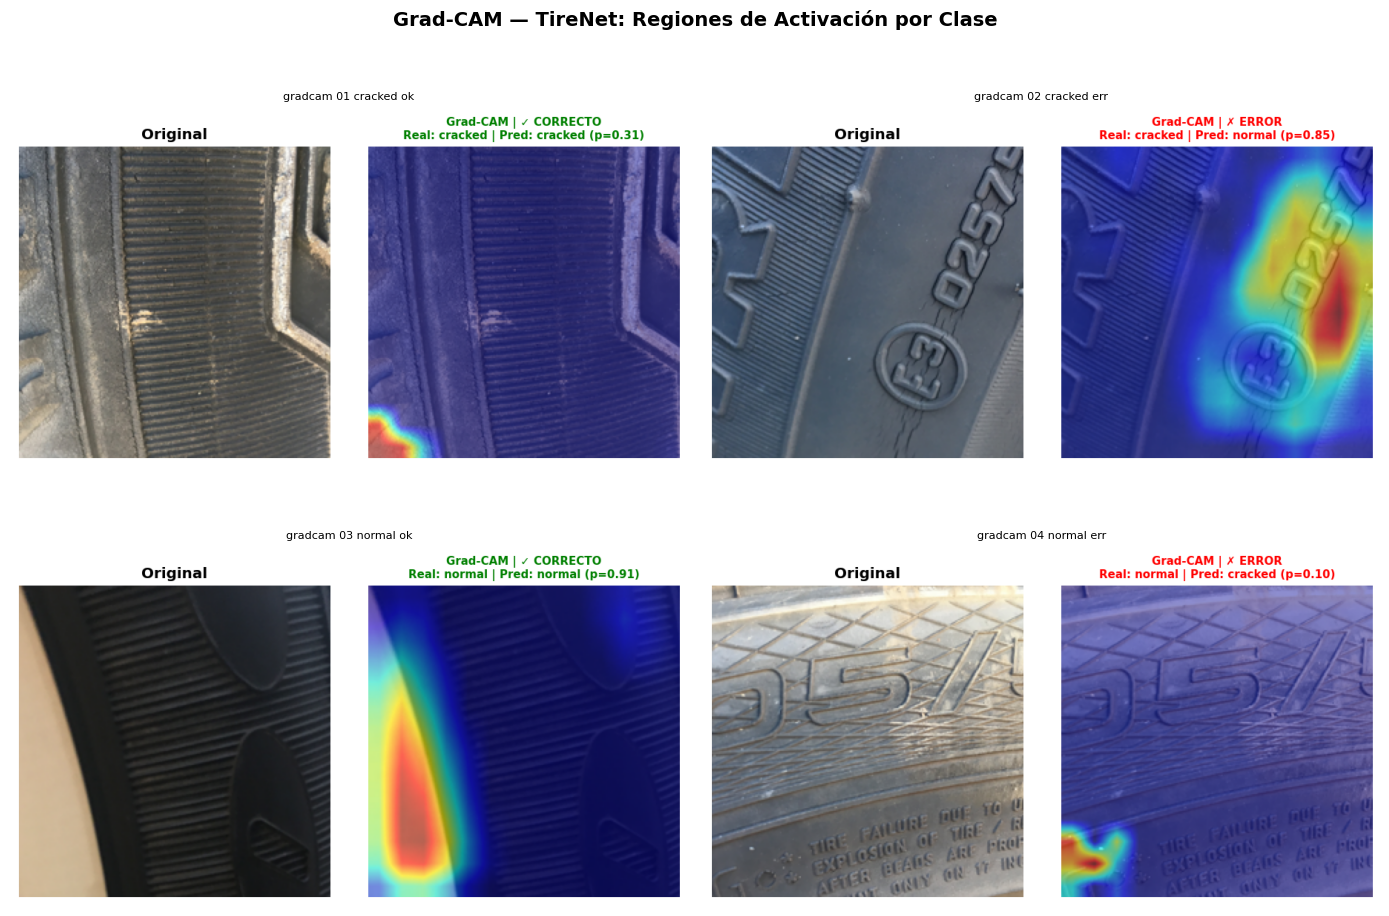

In [31]:
# ── Display all Grad-CAM images in a grid ─────────────────────────────────────
n = len(gradcam_files)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5))
fig.suptitle('Grad-CAM — TireNet: Regiones de Activación por Clase', fontsize=14, fontweight='bold')

for ax, fpath in zip(axes.flatten(), gradcam_files):
    img = Image.open(fpath)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(fpath.stem.replace('_', ' '), fontsize=8)

for ax in axes.flatten()[len(gradcam_files):]:
    ax.axis('off')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'gradcam_grid.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Sección 8 — Análisis Cualitativo de Fallos

Se identifican los ejemplos con **mayor error de confianza** (alta probabilidad predicha para la clase incorrecta). Para cada fallo se proporciona:
- Imagen original con overlay de Grad-CAM
- Tipo de error (Falso Positivo / Falso Negativo)
- Probabilidad asignada y clase verdadera
- Campo de hipótesis para completar en el análisis

In [32]:
# ── Extract worst failures (most confident wrong predictions) ─────────────────
df_errors = df_predictions[~df_predictions['correct']].copy()

# Sort by confidence in wrong prediction
df_errors['confidence_wrong'] = df_errors.apply(
    lambda r: r['prob_cracked'] if r['pred_label'] == 'cracked' else 1 - r['prob_cracked'],
    axis=1
)
df_errors = df_errors.sort_values('confidence_wrong', ascending=False)

# Take top 8 failures
top_failures = df_errors.head(8).reset_index(drop=True)
print(f'Total errores en test set: {len(df_errors)}')
print(f'Mostrando los {len(top_failures)} errores más confiados:\n')
print(top_failures[['true_label', 'pred_label', 'prob_cracked', 'confidence_wrong']].to_string())

Total errores en test set: 123
Mostrando los 8 errores más confiados:

  true_label pred_label  prob_cracked  confidence_wrong
0     normal    cracked      0.497803          0.497803
1    cracked     normal      0.518555          0.481445
2    cracked     normal      0.520020          0.479980
3    cracked     normal      0.524414          0.475586
4     normal    cracked      0.462158          0.462158
5    cracked     normal      0.551758          0.448242
6    cracked     normal      0.555664          0.444336
7    cracked     normal      0.557129          0.442871


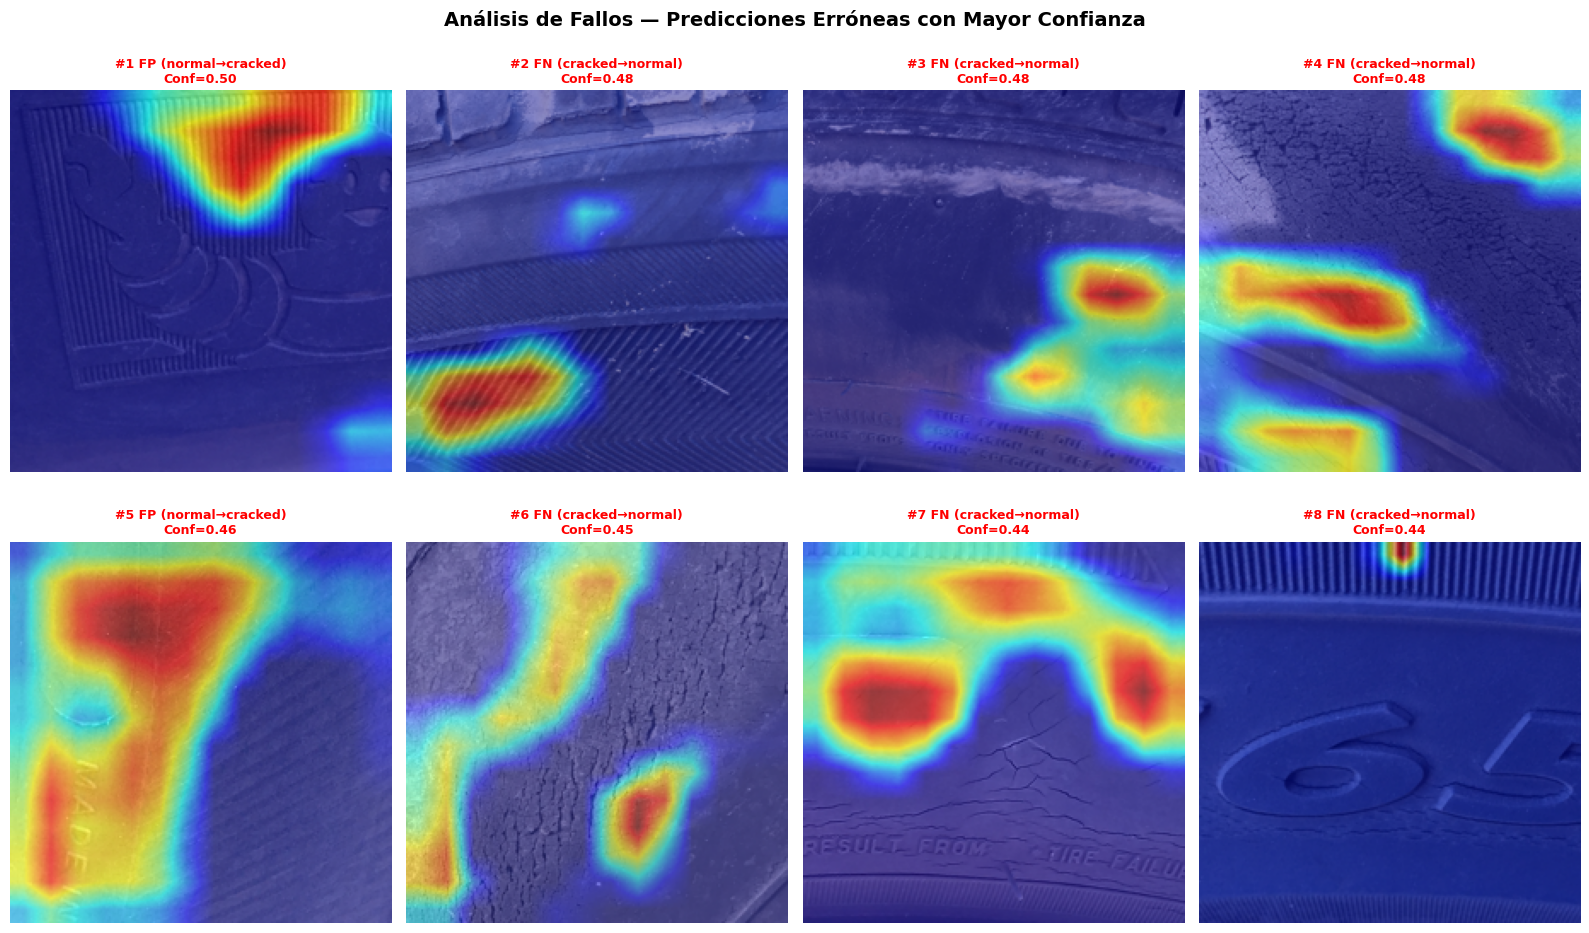

Guardado: failure_grid.png


In [33]:
# ── Generate failure grid with Grad-CAM ───────────────────────────────────────
n_fail = len(top_failures)
cols_f = 4
rows_f = (n_fail + cols_f - 1) // cols_f

fig, axes = plt.subplots(rows_f, cols_f, figsize=(16, rows_f * 5))
fig.suptitle('Análisis de Fallos — Predicciones Erróneas con Mayor Confianza',
             fontsize=14, fontweight='bold')

for i, (_, row) in enumerate(top_failures.iterrows()):
    ax = axes.flatten()[i] if rows_f > 1 else axes[i]
    img_pil = Image.open(row['image_path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np  = np.array(img_pil, dtype=np.float32) / 255.0

    tensor = transform_eval(img_pil).unsqueeze(0).to(DEVICE)

    # Binary scalar output → target index always 0
    targets = [ClassifierOutputTarget(0)]
    grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    ax.imshow(cam_image)
    error_type = 'FP (normal→cracked)' if row['pred_label'] == 'cracked' else 'FN (cracked→normal)'
    ax.set_title(f'#{i+1} {error_type}\nConf={row["confidence_wrong"]:.2f}',
                 fontsize=9, color='red', fontweight='bold')
    ax.axis('off')

for ax in axes.flatten()[n_fail:]:
    ax.axis('off')

plt.tight_layout()
fig.savefig(FAILURE_DIR / 'failure_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: failure_grid.png')

In [34]:
# ── Save failure analysis CSV (to fill in hypotheses manually) ────────────────
top_failures['error_type'] = top_failures.apply(
    lambda r: 'FP' if r['pred_label'] == 'cracked' and r['true_label'] == 'normal' else 'FN',
    axis=1
)
top_failures['hypothesis'] = ''  # <-- fill this manually in spreadsheet

cols_export = ['image_path', 'true_label', 'pred_label', 'prob_cracked',
               'confidence_wrong', 'error_type', 'hypothesis']
top_failures[cols_export].to_csv(FAILURE_DIR / 'failure_analysis.csv', index=False)
print('failure_analysis.csv guardado. Completa la columna "hypothesis" para el análisis cualitativo.')

failure_analysis.csv guardado. Completa la columna "hypothesis" para el análisis cualitativo.


---
## Sección 9 — Exportación de Artefactos

In [36]:
import shutil
from google.colab import files

shutil.make_archive("/content/nb1_cnn_scratch", "zip", "/content/outputs/nb1_cnn_scratch")
files.download("/content/nb1_cnn_scratch.zip")

shutil.make_archive("/content/sample_data", "zip", "/content/sample_data")
files.download("/content/sample_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Resumen de Resultados — Notebook 1

> **Completa esta sección después de ejecutar el notebook con los valores reales obtenidos.**

| Métrica | Valor |
|---|---|
| Accuracy (test) | `rellenar` |
| F1-Score macro (test) | `rellenar` |
| AUC-ROC (test) | `rellenar` |
| Mejor configuración (ablación) | `rellenar` |
| Épocas hasta early stopping | `rellenar` |
| Total parámetros TireNet | `rellenar` |

### Observaciones sobre Grad-CAM
> Describir qué regiones activan la predicción de daño en llantas cracked vs normal. ¿El modelo focaliza en grietas específicas o en regiones de textura global?

### Impacto del Desbalance
> Comparar Recall de la clase minoritaria con y sin WeightedRandomSampler. Cuantificar mejora en F1 macro.

### Hipótesis sobre Fallos Principales
| # | Tipo | Hipótesis |
|---|---|---|
| 1 | FP/FN | `rellenar` |
| 2 | FP/FN | `rellenar` |
| 3 | FP/FN | `rellenar` |
| 4 | FP/FN | `rellenar` |
| 5 | FP/FN | `rellenar` |